In [1]:
# import squidpy as sq
import scanpy as sc
import pandas as pd
from rich import print
import colorcet as cc
import matplotlib.pyplot as plt

In [5]:
# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"
sc.settings._vector_friendly = True

In [3]:
data_folder = "/home/nathanl/Data/VisiumHD_CRC/"

# Build adata

In [3]:
adata = sc.read_10x_h5(
    "/home/nathanl/Data/VisiumHD_CRC/segmented_outputs/filtered_feature_cell_matrix.h5",
    genome=None,  # genome key not needed for Visium
)

In [4]:
adata

AnnData object with n_obs × n_vars = 220703 × 18132
    var: 'gene_ids', 'feature_types', 'genome'

In [5]:
adata.obs_names

Index(['cellid_000000003-1', 'cellid_000000004-1', 'cellid_000000005-1',
       'cellid_000000006-1', 'cellid_000000007-1', 'cellid_000000008-1',
       'cellid_000000009-1', 'cellid_000000010-1', 'cellid_000000011-1',
       'cellid_000000012-1',
       ...
       'cellid_000268789-1', 'cellid_000268793-1', 'cellid_000268794-1',
       'cellid_000268795-1', 'cellid_000268801-1', 'cellid_000268804-1',
       'cellid_000268805-1', 'cellid_000268808-1', 'cellid_000268813-1',
       'cellid_000268814-1'],
      dtype='object', length=220703)

In [6]:
pd.read_parquet("/home/nathanl/Data/VisiumHD_CRC/Visium_HD_Human_Colon_Cancer_barcode_mappings.parquet")

,square_002um,square_008um,square_016um,cell_id,in_nucleus,in_cell
0,s_002um_00000_00000-1,s_008um_00000_00000-1,s_016um_00000_00000-1,None,False,False
1,s_002um_00000_00001-1,s_008um_00000_00000-1,s_016um_00000_00000-1,None,False,False
2,s_002um_00000_00002-1,s_008um_00000_00000-1,s_016um_00000_00000-1,None,False,False
3,s_002um_00000_00003-1,s_008um_00000_00000-1,s_016um_00000_00000-1,cellid_000244980-1,False,True
4,s_002um_00000_00004-1,s_008um_00000_00001-1,s_016um_00000_00000-1,cellid_000244980-1,False,True
...,...,...,...,...,...,...
11222495,s_002um_03349_03345-1,s_008um_00837_00836-1,s_016um_00418_00418-1,None,False,False
11222496,s_002um_03349_03346-1,s_008um_00837_00836-1,s_016um_00418_00418-1,None,False,False
11222497,s_002um_03349_03347-1,s_008um_00837_00836-1,s_016um_00418_00418-1,None,False,False
11222498,s_002um_03349_03348-1,s_008um_00837_00837-1,s_016um_00418_00418-1,None,False,False


In [7]:
import geopandas as gpd

# Load cell segmentations
gdf = gpd.read_file("/home/nathanl/Data/VisiumHD_CRC/segmented_outputs/cell_segmentations.geojson")

# Optionally inspect columns
print(gdf.columns)

Index(['cell_id', 'geometry'], dtype='object')

In [8]:
gdf

,cell_id,geometry
0,3,"POLYGON ((44562.8 3978.5, 44563 3963.9, 44570...."
1,4,"POLYGON ((44526.2 3985.3, 44526.5 3963.4, 4454..."
2,5,"POLYGON ((44606.6 3979.1, 44606.7 3971.8, 4459..."
3,6,"POLYGON ((44504.2 3992.3, 44504.3 3985, 44497 ..."
4,7,"POLYGON ((44708.6 4002.3, 44708.8 3987.7, 4470..."
...,...,...
220699,268804,"POLYGON ((64907.4 22056.2, 64907.5 22048.9, 64..."
220700,268805,"POLYGON ((63963.8 21612.8, 63963.9 21605.5, 63..."
220701,268808,"POLYGON ((63705.4 21821.3, 63705.9 21784.8, 63..."
220702,268813,"POLYGON ((64054.7 21365.7, 64054.9 21351.1, 64..."


In [9]:
print(gdf.crs)

EPSG:4326

In [10]:
# Format cell_id to match adata.obs.index format
gdf["cell_id"] = gdf["cell_id"].astype(int)
gdf["cell_id_str"] = gdf["cell_id"].apply(lambda x: f"cellid_{x:09d}-1")

gdf.set_crs(None, allow_override=True, inplace=True)
# Compute centroid coordinates
gdf["centroid_x"] = gdf.geometry.centroid.x
gdf["centroid_y"] = gdf.geometry.centroid.y

# Set index to match AnnData
gdf = gdf.set_index("cell_id_str")

# Join to adata.obs
adata.obs = adata.obs.join(gdf[["centroid_x", "centroid_y"]], how="left")

In [11]:
# Set spatial coordinates from centroids
adata.obsm["spatial"] = adata.obs[["centroid_x", "centroid_y"]].values.copy()

In [12]:
adata.obs.head()

,centroid_x,centroid_y
cellid_000000003-1,44579.452632,3955.094737
cellid_000000004-1,44540.618182,3974.545455
cellid_000000005-1,44607.894750,3961.369024
cellid_000000006-1,44510.564221,3958.831392
cellid_000000007-1,44715.969346,3962.082628


In [32]:
import numpy as np

for gene in ["EPCAM", "KRT19", "MKI67", "CD3D", "COL1A1"]:
    vals = adata[:, gene].X
    print(f"{gene}: min={np.min(vals)}, max={np.max(vals)}, mean={np.mean(vals)}")

EPCAM: min=0.0, max=40.0, mean=1.973484754562378
KRT19: min=0.0, max=7.0, mean=0.06079210340976715
MKI67: min=0.0, max=10.0, mean=0.1702015995979309
CD3D: min=0.0, max=5.0, mean=0.03280426561832428
COL1A1: min=0.0, max=278.0, mean=1.8737986087799072


In [13]:
adata.layers["log1p"] = np.log1p(adata.X)

NameError: name 'np' is not defined

In [14]:
adata.X[0].toarray().max()

np.float32(29.0)

In [16]:
adata.layers["counts"] = adata.X.copy()
adata.raw = adata.copy()

In [17]:
adata

AnnData object with n_obs × n_vars = 220703 × 18132
    obs: 'centroid_x', 'centroid_y'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
    layers: 'counts'

In [18]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=10000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    # batch_key="cell_source",
)

In [19]:
# adata = sc.read_10x_h5(
#     "/home/nathanl/Data/VisiumHD_CRC/segmented_outputs/filtered_feature_cell_matrix.h5",
#     genome=None,  # genome key not needed for Visium
# )


sc.write("/home/nathanl/Data/VisiumHD_CRC/adata.h5ad", adata)

/tmp/ipykernel_645544/4131057585.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["EPCAM", "KRT19", "MKI67", "CD3D", "COL1A1"], spot_size=50, layer="log1p", vmax='p99', ncols=3)


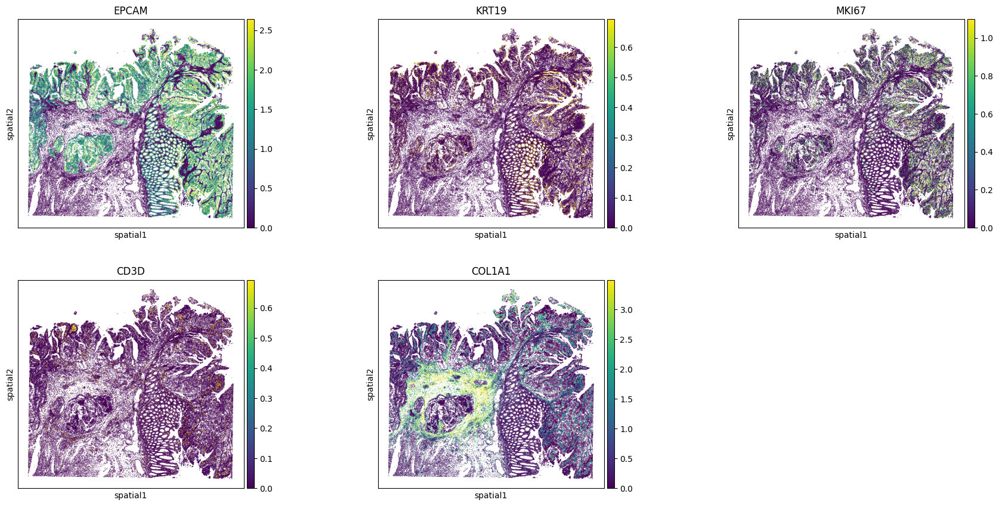

In [27]:
sc.pl.spatial(
    adata, color=["EPCAM", "KRT19", "MKI67", "CD3D", "COL1A1"], spot_size=50, layer="log1p", vmax="p99", ncols=3
)

In [28]:
meta = pd.read_csv("/home/nathanl/Data/VisiumHD_CRC/HumanColonCancer_VisiumHD/MetaData/SingleCell_MetaData.csv.gz")
meta.head()

,Barcode,Patient,BC,QCFilter,Level1,Level2,UMAP1,UMAP2
0,AAACAAGCAACAGCACACTTTAGG-1,P2CRC,BC1,Remove,QC_Filtered,QC_Filtered,3.986881,4.353043
1,AAACAAGCAACAGCTAACTTTAGG-1,P2CRC,BC1,Keep,B cells,Plasma,-10.475996,-0.267628
2,AAACAAGCAACTGTTCACTTTAGG-1,P2CRC,BC1,Keep,T cells,CD4 T cell,11.040590,-5.051295
3,AAACAAGCAAGGCCTGACTTTAGG-1,P2CRC,BC1,Keep,Tumor,Tumor III,0.473911,3.721375
4,AAACAAGCACATAGTGACTTTAGG-1,P2CRC,BC1,Keep,Tumor,Tumor III,2.316584,4.809119


In [36]:
meta.shape

(279609, 8)

In [30]:
# Load the barcode mapping
barcode_map = pd.read_parquet(data_folder + "Visium_HD_Human_Colon_Cancer_barcode_mappings.parquet")
barcode_map = barcode_map.set_index("cell_id")  # or "cellid" — check the actual column name

# Preview it
barcode_map.head()

,square_002um,square_008um,square_016um,in_nucleus,in_cell
cell_id,,,,,
None,s_002um_00000_00000-1,s_008um_00000_00000-1,s_016um_00000_00000-1,False,False
None,s_002um_00000_00001-1,s_008um_00000_00000-1,s_016um_00000_00000-1,False,False
None,s_002um_00000_00002-1,s_008um_00000_00000-1,s_016um_00000_00000-1,False,False
cellid_000244980-1,s_002um_00000_00003-1,s_008um_00000_00000-1,s_016um_00000_00000-1,False,True
cellid_000244980-1,s_002um_00000_00004-1,s_008um_00000_00001-1,s_016um_00000_00000-1,False,True


In [32]:
# Load the deconvolution results
df_deconv = pd.read_parquet(data_folder + "HumanColonCancer_VisiumHD/MetaData/P1CRC_Metadata.parquet")

# Preview
df_deconv.head()

,barcode,tissue,X,Y,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2,Periphery,UnsupervisedL1,UnsupervisedL2,MacrophageSubtype,GobletSubcluster
0,s_008um_00000_00000-1,0,-2.042794,-308.764636,None,None,None,None,None,None,None,None
1,s_008um_00000_00001-1,0,-1.796281,-308.766918,None,None,None,None,None,None,None,None
2,s_008um_00000_00002-1,0,-1.549768,-308.769200,None,None,None,None,None,None,None,None
3,s_008um_00000_00003-1,0,-1.303254,-308.771481,None,None,None,None,None,None,None,None
4,s_008um_00000_00004-1,0,-1.056741,-308.773763,None,None,None,None,None,None,None,None


In [38]:
# Load the deconvolution results
df_deconv = pd.read_csv(data_folder + "HumanColonCancer_VisiumHD/MetaData/DeconvolutionResults_P1CRC.csv.gz")

# Preview
df_deconv.head()

/tmp/ipykernel_645544/602545192.py:2: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_deconv = pd.read_csv(data_folder + "HumanColonCancer_VisiumHD/MetaData/DeconvolutionResults_P1CRC.csv.gz")


,barcode,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2
0,s_008um_00000_00000-1,NaN,NaN,NaN
1,s_008um_00000_00001-1,NaN,NaN,NaN
2,s_008um_00000_00002-1,NaN,NaN,NaN
3,s_008um_00000_00003-1,NaN,NaN,NaN
4,s_008um_00000_00004-1,NaN,NaN,NaN


In [35]:
import scanpy as sc

adata_filtered = sc.read_10x_mtx(
    data_folder + "segmented_outputs/raw_feature_cell_matrix/",
    var_names="gene_symbols",  # or 'gene_ids', depending on what you need
    make_unique=True,
)

print(adata_filtered)
print(adata_filtered.obs_names[:5])

AnnData object with n_obs × n_vars = 220704 × 39125
    var: 'gene_ids', 'feature_types'
Index(['cellid_000000003-1', 'cellid_000000004-1', 'cellid_000000005-1',
       'cellid_000000006-1', 'cellid_000000007-1'],
      dtype='object')


In [34]:
import geopandas as gpd

gdf = gpd.read_file(data_folder + "segmented_outputs/graphclust_annotated_cell_segmentations.geojson")
print(gdf.columns)
print(gdf.head())


Index(['cell_id', 'classification', 'geometry'], dtype='object')
   cell_id                                 classification  \
0        3  {'name': 'Cluster-1', 'color': [60, 180, 75]}   
1        4  {'name': 'Cluster-1', 'color': [60, 180, 75]}   
2        5  {'name': 'Cluster-1', 'color': [60, 180, 75]}   
3        6  {'name': 'Cluster-1', 'color': [60, 180, 75]}   
4        7  {'name': 'Cluster-1', 'color': [60, 180, 75]}   

                                            geometry  
0  POLYGON ((44562.8 3978.5, 44563 3963.9, 44570....  
1  POLYGON ((44526.2 3985.3, 44526.5 3963.4, 4454...  
2  POLYGON ((44606.6 3979.1, 44606.7 3971.8, 4459...  
3  POLYGON ((44504.2 3992.3, 44504.3 3985, 44497 ...  
4  POLYGON ((44708.6 4002.3, 44708.8 3987.7, 4470...  


# adata

In [23]:
import h5py
import pandas as pd
import numpy as np
from scipy import sparse
import anndata as ad

filename = "/home/nathanl/Data/VisiumHD_CRC/adata.h5ad"
output_file = filename.replace(".h5ad", "_recovered.h5ad")


# ----------------------------
# Helper: read obs / var safely
# ----------------------------
def read_group_as_df(group: h5py.Group) -> pd.DataFrame:
    data = {}
    for k in group.keys():
        obj = group[k]
        if isinstance(obj, h5py.Dataset):
            try:
                data[k] = obj[:]
            except Exception as e:
                print(f"⚠️ Could not read column '{k}': {e}")
        else:
            print(f"⚠️ Skipping non-dataset key in group: {k}")

    df = pd.DataFrame(data)

    # Handle AnnData index correctly
    if "_index" in group.attrs:
        idx = group.attrs["_index"]

        # Case 1: index is stored as a column name
        if isinstance(idx, str) and idx in df.columns:
            df.index = df[idx].astype(str)

        # Case 2: index stored directly as array
        elif hasattr(idx, "__len__"):
            df.index = pd.Index(idx.astype(str), name="index")

    return df


with h5py.File(filename, "r") as f:
    print("Available top-level groups:")
    print(list(f.keys()))

    # -----------------------
    # 1. Load X
    # -----------------------
    X = None

    if "X" in f:
        # Try dense first
        try:
            X = f["X"][()]
            print(f"✅ Loaded X as dense matrix {X.shape}")
        except Exception as e_dense:
            print("❌ Dense X failed:", e_dense)

            # Try sparse CSR
            try:
                Xg = f["X"]
                data = Xg["data"][:]
                indices = Xg["indices"][:]
                indptr = Xg["indptr"][:]

                n_obs = f["obs"][f["obs"].attrs["_index"]].shape[0]
                n_var = f["var"][f["var"].attrs["_index"]].shape[0]

                X = sparse.csr_matrix((data, indices, indptr), shape=(n_obs, n_var))
                print(f"✅ Loaded X as sparse CSR {X.shape}")
            except Exception as e_sparse:
                print("❌ Sparse X failed:", e_sparse)

    # -----------------------
    # 2. Load obs / var
    # -----------------------
    obs, var = None, None

    try:
        obs = read_group_as_df(f["obs"])
        print("✅ Loaded obs", obs.shape)
    except Exception as e:
        print("❌ obs failed:", e)

    try:
        var = read_group_as_df(f["var"])
        print("✅ Loaded var", var.shape)
    except Exception as e:
        print("❌ var failed:", e)

    # -----------------------
    # 3. Construct AnnData
    # -----------------------
    if X is None or obs is None or var is None:
        raise RuntimeError("❌ Cannot recover AnnData: X / obs / var missing")

    # Drop reserved column name if present
    for df in (obs, var):
        if "_index" in df.columns:
            print("⚠️ Removing reserved column '_index'")
            df.drop(columns="_index", inplace=True)

    adata = ad.AnnData(X=X, obs=obs, var=var)

    # -----------------------
    # 4. Recover obsm (skip broken keys)
    # -----------------------
    if "obsm" in f:
        for k in f["obsm"].keys():
            try:
                obj = f["obsm"][k]
                if isinstance(obj, h5py.Dataset):
                    adata.obsm[k] = obj[:]
                    print(f"✅ obsm['{k}'] loaded")
                else:
                    print(f"⚠️ obsm['{k}'] skipped (not dataset)")
            except Exception as e:
                print(f"❌ obsm['{k}'] broken:", e)

    # -----------------------
    # 5. Recover layers (optional)
    # -----------------------
    if "layers" in f:
        for k in f["layers"].keys():
            try:
                obj = f["layers"][k]
                if isinstance(obj, h5py.Dataset):
                    adata.layers[k] = obj[:]
                    print(f"✅ layer '{k}' loaded")
            except Exception:
                pass

    # -----------------------
    # 6. Recover uns (lightweight only)
    # -----------------------
    if "uns" in f:
        for k in f["uns"].keys():
            try:
                obj = f["uns"][k]
                if isinstance(obj, h5py.Dataset):
                    adata.uns[k] = obj[()]
            except Exception:
                pass
    # Convert any bytes → str in .uns
    for k, v in list(adata.uns.items()):
        if isinstance(v, bytes):
            try:
                adata.uns[k] = v.decode("utf-8")
                print(f"✅ Converted .uns['{k}'] from bytes to string")
            except Exception as e:
                print(f"⚠️ Skipping .uns['{k}']: failed to decode bytes → str:", e)
                del adata.uns[k]  # Optional: delete if can't decode

    # -----------------------
    # 7. Save recovered object
    # -----------------------
    adata.write(output_file)
    print(f"\n🎉 SUCCESS: recovered AnnData saved to\n{output_file}")

Available top-level groups:

['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']

❌ Dense X failed: Accessing a group is done with bytes or str, not <class 'tuple'>

✅ Loaded X as sparse CSR (220289, 10000)

⚠️ Skipping non-dataset key in group: _indices

...

✅ obsm['qz1_m_niche_ct'] loaded

✅ obsm['spatial'] loaded

✅ Converted .uns['_scvi_manager_uuid'] from bytes to string

✅ Converted .uns['_scvi_uuid'] from bytes to string

🎉 SUCCESS: recovered AnnData saved to
/home/nathanl/Data/VisiumHD_CRC/adata_recovered.h5ad

In [21]:
adata = sc.read_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_recovered.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'region_label_colors', 
'resolvi_leiden_1.0_colors', 'resolvi_leiden_256_colors', 'resolvi_leiden_256_epochs150_colors', 
'resolvi_leiden_colors', 'sample_colors'
    obsm: 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 'X_spatial', 'X_umap', 
'distance_neighbor', 'index_neighbor', 'niche_distances', 'niche_indexes', 'qz1_m_niche_ct', 'spatial'

In [26]:
adata_orig = sc.read_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata.h5ad")
sc.pp.filter_cells(adata_orig, min_counts=10)
print(adata_orig)

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: 'centroid_x', 'centroid_y', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 
'variances_norm'
    uns: 'hvg'
    obsm: 'spatial'
    layers: 'counts'

In [27]:
adata.layers['counts'] = adata_orig.layers['counts'].copy()

In [29]:
# adata.write_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_recovered.h5ad")

## cell typing

In [ ]:
adata = sc.read_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_resolvi.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'region_label_colors', 
'resolvi_leiden_1.0_colors', 'resolvi_leiden_256_colors', 'resolvi_leiden_256_epochs150', 
'resolvi_leiden_256_epochs150_colors', 'resolvi_leiden_colors', 'sample_colors', 'umap'
    obsm: 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 'X_spatial', 'X_umap', 
'distance_neighbor', 'index_neighbor', 'niche_distances', 'niche_indexes', 'qz1_m_niche_ct', 'spatial'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [39]:
# Make a copy of the raw counts from `.X`
adata.layers["log_norm"] = adata.layers["counts"].copy()
# Apply total-count normalization (library size normalization)
sc.pp.normalize_total(adata, target_sum=1e4, layer="log_norm", inplace=True)
# Apply log1p transformation
sc.pp.log1p(adata, layer="log_norm")

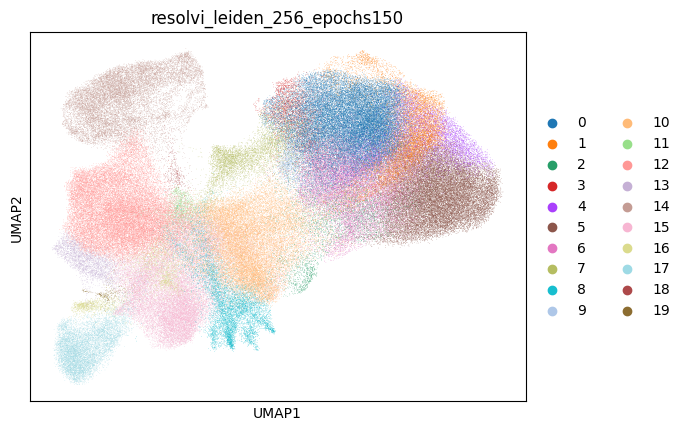

In [40]:
sc.pl.umap(
    adata,
    color=["resolvi_leiden_256_epochs150"],
    wspace=0.4,
    # save="_resolvi_leiden.png",
)

In [10]:
# sc.tl.leiden(adata, resolution=1, key_added="resolvi_leiden_1.0", flavor="igraph")

In [41]:
sc.tl.rank_genes_groups(adata, groupby="resolvi_leiden_256_epochs150", method="wilcoxon", layer="log_norm", use_raw=False)

In [42]:
import pandas as pd

# Extract top 10 genes per cluster
top_n = 15
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names  # cluster names

# Build DataFrame of top genes
top_genes = {group: result["names"][group][:top_n].tolist() for group in groups}

top_genes_df = pd.DataFrame(top_genes)
top_genes_df.index = [f"Rank_{i+1}" for i in range(top_n)]
top_genes_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Rank_1,CEACAM6,CEACAM6,SPP1,MUC13,FABP1,CEACAM6,KRT23,CXCL8,VIM,SELENBP1,VIM,VIM,IGKC,IGKC,PIGR,COL3A1,VIM,DES,SELENOP,VIM
Rank_2,LCN2,PHGR1,APOE,PI3,PHGR1,MT-ND4L,APCDD1,SRGN,IGFBP7,OAS1,SPARC,CD74,JCHAIN,IGHG1,FCGBP,COL1A1,TAGLN,TAGLN,APOE,SPARC
Rank_3,CD24,S100A10,IFI30,LCN2,CEACAM6,LGR5,KRT8,SOD2,PECAM1,WARS1,COL3A1,LCP1,IGHG1,XBP1,TSPAN8,COL1A2,DES,MYH11,CD74,CLU
Rank_4,NCOA7,CD24,CTSB,ATP1B1,MT-ND4L,MME,MME,S100A9,A2M,TAP1,COL4A1,SRGN,TXNDC5,JCHAIN,MUC2,SPARC,A2M,MYL9,A2M,NRXN1
Rank_5,MYC,KRT18,MT-ND4L,KRT8,NQO1,GLCE,KRT18,G0S2,SPARCL1,IFI27,COL1A1,TRBC2,XBP1,MGP,AGR2,MMP2,IGKC,ACTG2,C1QC,ITGB8
Rank_6,CXCL2,KRT8,PSAP,KRT18,CD24,VAV3,AXIN2,S100A8,VWF,OAS2,LGALS1,TRAC,IGHA1,PIM2,PHGR1,VIM,GREM1,CSRP1,PSAP,APOD
Rank_7,GPRC5A,GPRC5A,CD68,TRIM31,HSPE1,PHGR1,CEACAM6,IL1B,ENG,MX1,IGFBP7,CORO1A,IGHM,COL3A1,LCN2,LUM,MYH11,MYLK,CTSB,CRYAB
Rank_8,GPX2,EREG,VIM,ID1,GSTP1,LBR,CLDN4,BCL2A1,AQP1,STAT1,COL1A2,MMP12,MZB1,MZB1,CLCA1,COL6A3,MYL9,TPM2,LYZ,L1CAM
Rank_9,PTP4A3,MYC,LAPTM5,CEACAM6,MYC,GPCPD1,PRSS23,IL1RN,SPARC,ID1,MMP12,LSP1,CD74,MMP2,TSPAN1,DCN,COL3A1,SYNPO2,SLC40A1,IGKC
Rank_10,EREG,TFRC,CD74,TMEM45B,PDHA1,MYC,NKD1,NAMPT,EPAS1,PARP14,A2M,WIPF1,PIM2,SFRP2,LGALS4,COL5A1,ACTG2,CALD1,CD68,LGALS1


In [44]:
top_genes_df.to_dict(orient="list")

{'0': ['CEACAM6',
  'LCN2',
  'CD24',
  'NCOA7',
  'MYC',
  'CXCL2',
  'GPRC5A',
  'GPX2',
  'PTP4A3',
  'EREG',
  'CLDN4',
  'CXCL3',
  'PRSS23',
  'KRT18',
  'NQO1'],
 '1': ['CEACAM6',
  'PHGR1',
  'S100A10',
  'CD24',
  'KRT18',
  'KRT8',
  'GPRC5A',
  'EREG',
  'MYC',
  'TFRC',
  'FABP1',
  'CLDN4',
  'GPCPD1',
  'EGR1',
  'PLBD1'],
 '2': ['SPP1',
  'APOE',
  'IFI30',
  'CTSB',
  'MT-ND4L',
  'PSAP',
  'CD68',
  'VIM',
  'LAPTM5',
  'CD74',
  'MMP12',
  'TYROBP',
  'LYZ',
  'GPNMB',
  'CTSD'],
 '3': ['MUC13',
  'PI3',
  'LCN2',
  'ATP1B1',
  'KRT8',
  'KRT18',
  'TRIM31',
  'ID1',
  'CEACAM6',
  'TMEM45B',
  'CKB',
  'TSPAN8',
  'ERO1A',
  'TM4SF1',
  'PDZK1IP1'],
 '4': ['FABP1',
  'PHGR1',
  'CEACAM6',
  'MT-ND4L',
  'NQO1',
  'CD24',
  'HSPE1',
  'GSTP1',
  'MYC',
  'PDHA1',
  'FERMT1',
  'MCM4',
  'KRT18',
  'MAL2',
  'PRSS23'],
 '5': ['CEACAM6',
  'MT-ND4L',
  'LGR5',
  'MME',
  'GLCE',
  'VAV3',
  'PHGR1',
  'LBR',
  'GPCPD1',
  'MYC',
  'AMACR',
  'FERMT1',
  'CD24',
  'SESN1

In [47]:
# cluster_annotations = {
#     "0": "Tumor (stem-like)",
#     "1": "Plasma B cells",
#     "2": "Tumor (proliferative)",
#     "3": "Proliferating macrophages",
#     "4": "Fibroblasts",
#     "5": "Tumor (Wnt/EMT-like)",
#     "6": "Goblet cells",
#     "7": "Endothelial/Pericytes",
#     "8": "Tumor (epithelial)",
#     "9": "Smooth muscle",
#     "10": "Tumor/Enterocyte",
#     "11": "Tumor (GPRC5A-high)",
#     "12": "Tumor (EMT)",
#     "13": "Neutrophils",
#     "14": "Endothelial",
#     "15": "Myofibroblasts",
#     "16": "Enterocytes",
#     "17": "Macrophages (SPP1+ TAM-like)",
#     "18": "Tumor (interferon-high)",
#     "19": "Macrophages (C1QC+)",
#     "20": "Stromal/Fibroblast",
#     "21": "Plasma B cells"
# }
# cluster_annotations_coarse = {
#     "0": "Tumor",
#     "1": "Plasma B cells",
#     "2": "Tumor",
#     "3": "Macrophages",
#     "4": "Fibroblasts",
#     "5": "Tumor",
#     "6": "Goblet cells",
#     "7": "Endothelial/Pericytes",
#     "8": "Tumor",
#     "9": "Smooth muscle",
#     "10": "Tumor/Enterocyte",
#     "11": "Tumor",
#     "12": "Tumor",
#     "13": "Neutrophils",
#     "14": "Endothelial",
#     "15": "Myofibroblasts",
#     "16": "Enterocytes",
#     "17": "Macrophages",
#     "18": "Tumor",
#     "19": "Macrophages",
#     "20": "Stromal/Fibroblast",
#     "21": "Plasma B cells"
# }

cluster_annotations = {
    "0": "Tumor (GPRC5A-high)",  # CEACAM6, LCN2, MYC, GPRC5A
    "1": "Tumor (epithelial-like)",  # CEACAM6, KRTs, MYC, FABP1
    "2": "Macrophages (TAM-like)",  # SPP1, APOE, CD68, GPNMB
    "3": "Tumor (hypoxic)",  # MUC13, LCN2, CEACAM6, TMEM45B
    "4": "Tumor (cycling-like)",  # MYC, MCM4, KRT18, FABP1
    "5": "Tumor (LGR5+ stem-like)",  # LGR5, CEACAM6, MYC
    "6": "Tumor (Wnt/EMT-like)",  # APCDD1, AXIN2, NKD1, PRSS23
    "7": "Neutrophils / Inflammatory myeloid",  # CXCL8, S100A8/A9, IL1B
    "8": "Endothelial cells",  # PECAM1, VWF, SPARCL1, AQP1
    "9": "Interferon-response epithelial",  # OAS1/2, MX1, ISG15, CEACAM6
    "10": "Stromal (Fibroblast-like)",  # VIM, SPARC, COL1A1/2, COL4A1
    "11": "Lymphoid (T cells / ILC-like)",  # TRBC2, TRAC, CORO1A, CD74
    "12": "Plasma B cells",  # IGKC, IGHG1, IGHA1, XBP1
    "13": "Plasma B cells / Fibroblast mix",  # IGKC, IGHG1, COL3A1
    "14": "Goblet cells",  # MUC2, FCGBP, TFF3, PIGR
    "15": "Myofibroblasts",  # COL1A1/2, TAGLN, AEBP1
    "16": "Smooth muscle",  # DES, MYH11, ACTG2, CSRP1
    "17": "Smooth muscle",  # MYH11, MYL9, ACTA2
    "18": "Macrophages (C1QC+)",  # C1QA/B/C, APOE, CD68, SLC40A1
    "19": "Glial-like / Stromal",  # CRYAB, NRXN1, APOD, S100B
}
cluster_annotations_coarse = {
    "0": "Tumor",  # CEACAM6, LCN2, MYC, GPRC5A
    "1": "Tumor",  # CEACAM6, KRTs, MYC, FABP1
    "2": "Macrophages",  # SPP1, APOE, CD68, GPNMB
    "3": "Tumor",  # MUC13, LCN2, CEACAM6, TMEM45B
    "4": "Tumor",  # MYC, MCM4, KRT18, FABP1
    "5": "Tumor",  # LGR5, CEACAM6, MYC
    "6": "Tumor",  # APCDD1, AXIN2, NKD1, PRSS23
    "7": "Neutrophils / Inflammatory myeloid",  # CXCL8, S100A8/A9, IL1B
    "8": "Endothelial cells",  # PECAM1, VWF, SPARCL1, AQP1
    "9": "Interferon-response epithelial",  # OAS1/2, MX1, ISG15, CEACAM6
    "10": "Stromal (Fibroblast-like)",  # VIM, SPARC, COL1A1/2, COL4A1
    "11": "Lymphoid (T cells / ILC-like)",  # TRBC2, TRAC, CORO1A, CD74
    "12": "Plasma B cells",  # IGKC, IGHG1, IGHA1, XBP1
    "13": "Plasma B cells / Fibroblast mix",  # IGKC, IGHG1, COL3A1
    "14": "Goblet cells",  # MUC2, FCGBP, TFF3, PIGR
    "15": "Myofibroblasts",  # COL1A1/2, TAGLN, AEBP1
    "16": "Smooth muscle",  # DES, MYH11, ACTG2, CSRP1
    "17": "Smooth muscle",  # MYH11, MYL9, ACTA2
    "18": "Macrophages",  # C1QA/B/C, APOE, CD68, SLC40A1
    "19": "Glial-like / Stromal",  # CRYAB, NRXN1, APOD, S100B
}
adata.obs["cell_type"] = adata.obs["resolvi_leiden_256_epochs150"].map(cluster_annotations)
adata.obs["cell_type_coarse"] = adata.obs["resolvi_leiden_256_epochs150"].map(cluster_annotations_coarse)

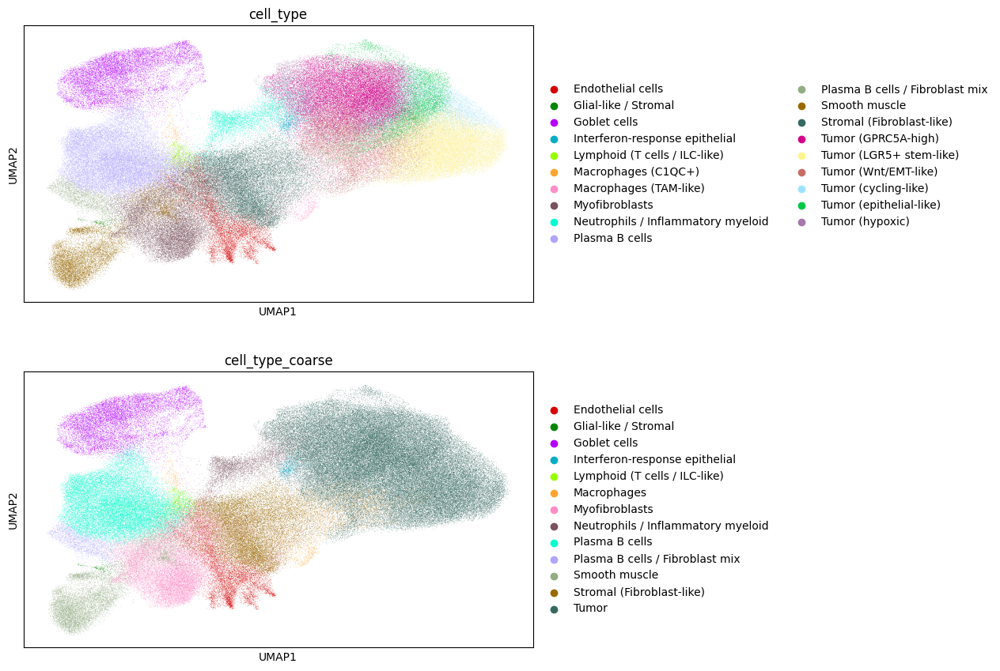

In [49]:
sc.pl.umap(
    adata,
    color=["cell_type", "cell_type_coarse"], 
    ncols=1,
    wspace=0.4,
    # save="_resolvi_leiden.png",
    palette=cc.glasbey_light
)

In [51]:
adata.write_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_resolvi_annotated.h5ad")

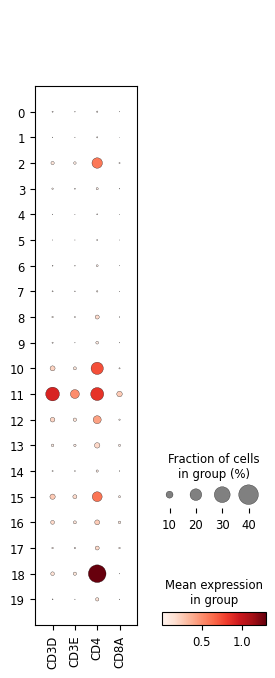

In [46]:
sc.pl.dotplot(adata, ["CD3D", "CD3E", "CD4", "CD8A"], groupby="resolvi_leiden_256_epochs150")

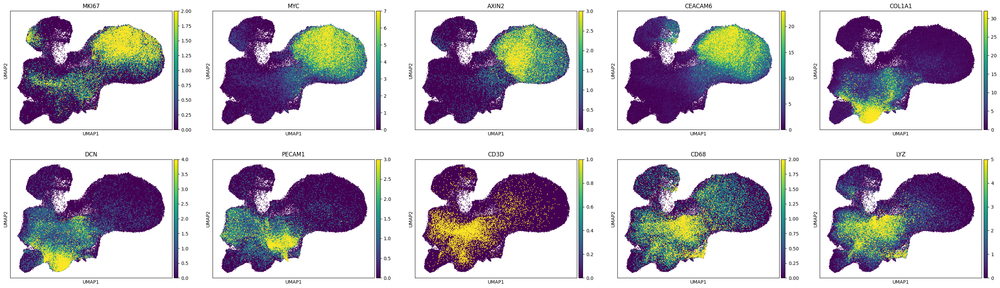

In [17]:
genes_to_plot = [
    "MKI67",
    "MYC",
    "AXIN2",
    "CEACAM6",  # cancer
    "COL1A1",
    "DCN",
    "PECAM1",  # stroma
    "CD3D",
    "CD68",
    "LYZ",  # immune
]

sc.pl.umap(
    adata,
    color=genes_to_plot,
    ncols=5,
    cmap="viridis",  # or 'RdBu_r', 'plasma', etc.
    size=10,
    vmax="p99",  # clip to avoid outliers
)

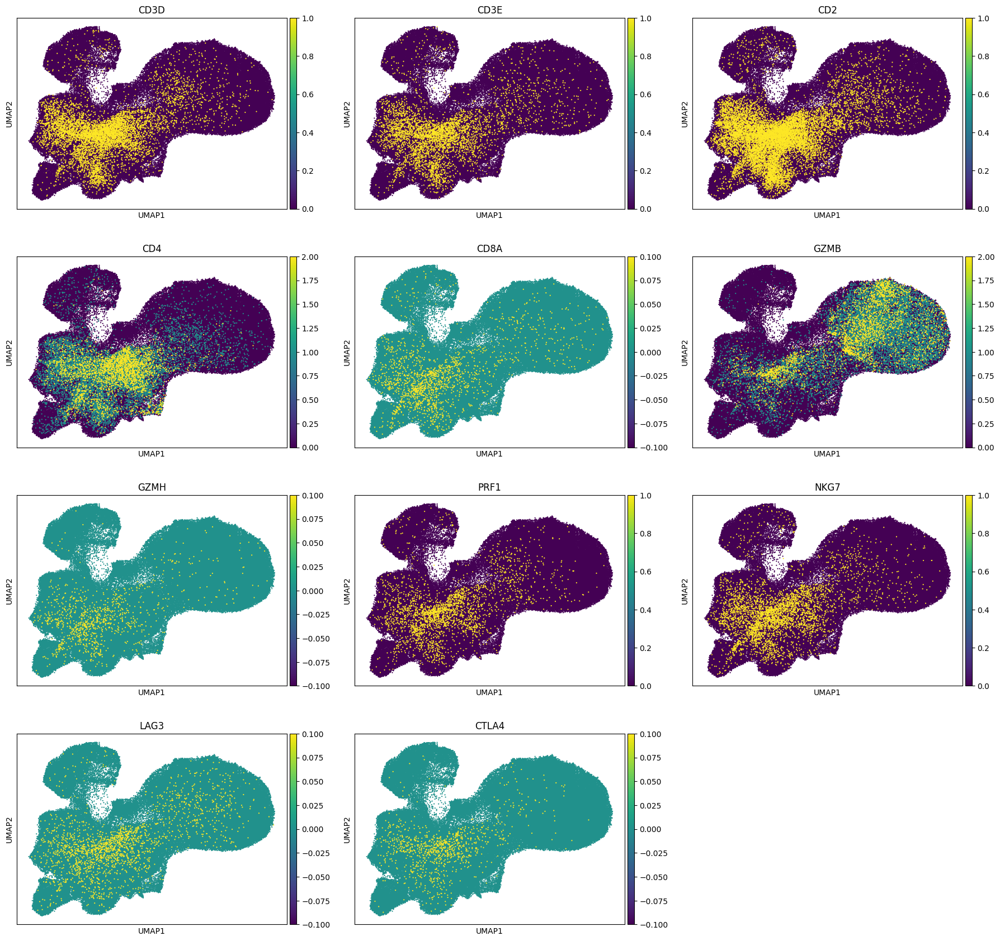

In [24]:
import scanpy as sc

# List of key T cell marker genes
tcell_markers = [
    "CD3D",
    "CD3E",
    "CD2",  # Pan-T
    "CD4",  # CD4+ T cells
    "CD8A",
    # "CD8B",  # CD8+ cytotoxic T cells
    "GZMB",
    "GZMH",
    "PRF1",
    "NKG7",  # Cytotoxic granules
    # "PDCD1",
    "LAG3",
    "CTLA4",  # Exhaustion markers
]

# Plot them on the UMAP
sc.pl.umap(adata, color=tcell_markers, ncols=3, cmap="viridis", vmax="p99", size=10)

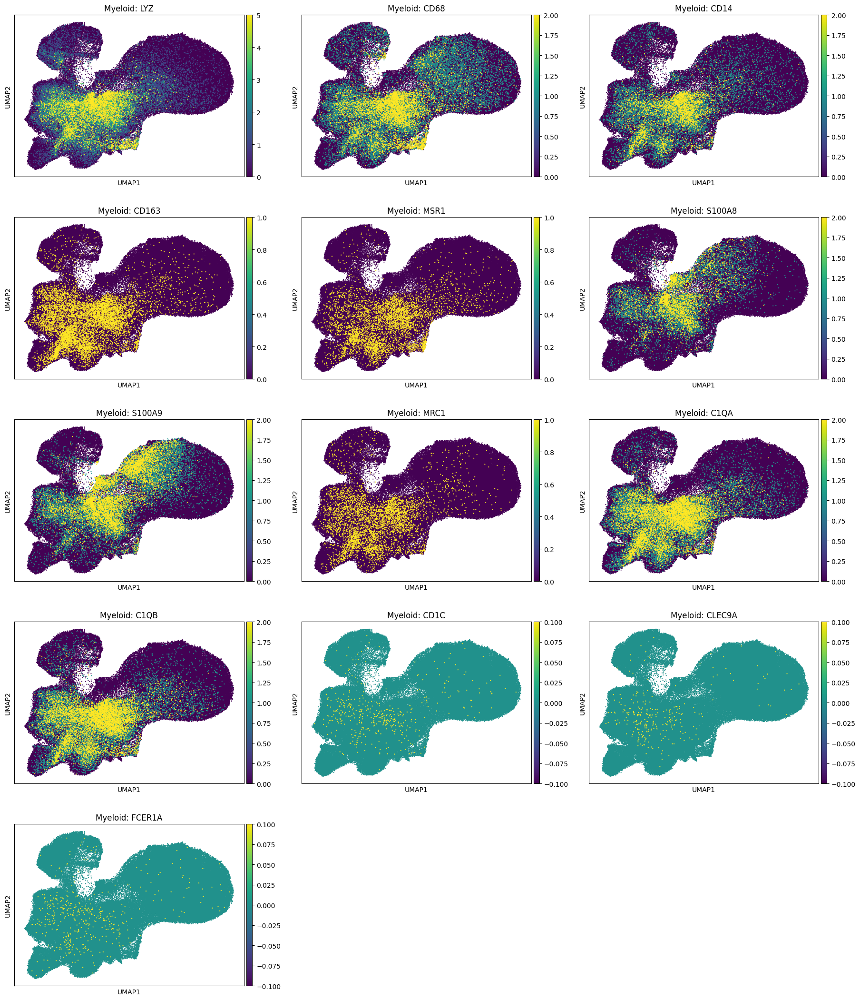

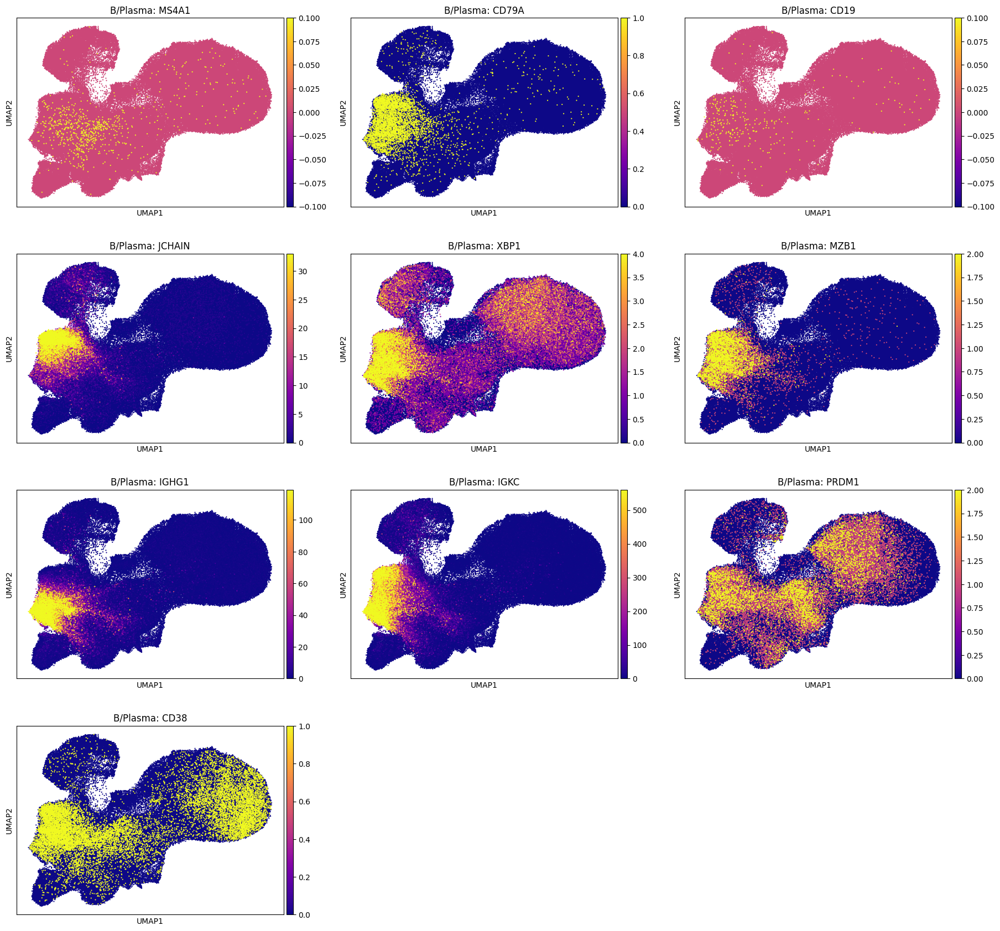

In [26]:
# Myeloid markers
myeloid_markers = [
    "LYZ",
    "CD68",
    "CD14",
    "CD163",
    "MSR1",
    "S100A8",
    "S100A9",
    "MRC1",
    "C1QA",
    "C1QB",
    "CD1C",
    "CLEC9A",
    "FCER1A",
]

# Plasma/B cell markers
bcell_markers = [
    "MS4A1",
    "CD79A",
    "CD19",  # B cells
    "JCHAIN",
    "XBP1",
    "MZB1",  # Plasma
    "IGHG1",
    "IGKC",
    "PRDM1",
    "CD38",
]

# Plot UMAPs
sc.pl.umap(adata, color=myeloid_markers, ncols=3, cmap="viridis", title=[f"Myeloid: {g}" for g in myeloid_markers], vmax="p99", size=10)
sc.pl.umap(adata, color=bcell_markers, ncols=3, cmap="plasma", title=[f"B/Plasma: {g}" for g in bcell_markers], vmax="p99", size=10)

# simple niches

In [24]:
adata = sc.read_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_resolvi_annotated.h5ad")

In [5]:
adata.obs['sample'] = 'Visium HD CRC'

In [6]:
setup_kwargs = {
    "sample_key": 'sample',
    "labels_key": "cell_type",
    "cell_coordinates_key": "spatial",
    "expression_embedding_key": "X_resolvi_256",
    "expression_embedding_niche_key": "qz1_m_niche_ct",
    "niche_composition_key": "neighborhood_composition",
    "niche_indexes_key": "niche_indexes",
    "niche_distances_key": "niche_distances",
}
import scvi
scvi.external.SCVIVA.preprocessing_anndata(
    adata,
    k_nn=20,
    **setup_kwargs,
)

Saved niche_indexes and niche_distances in adata.obsm

Saved neighborhood_composition in adata.obsm

Saved qz1_m_niche_ct in adata.obsm

In [7]:
print(adata)

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'cell_type_colors', 'log1p', 'neighbors', 
'rank_genes_groups', 'region_label_colors', 'resolvi_leiden_1.0_colors', 'resolvi_leiden_256_colors', 
'resolvi_leiden_256_epochs150', 'resolvi_leiden_256_epochs150_colors', 'resolvi_leiden_colors', 'sample_colors', 
'umap', 'cell_type_to_int'
    obsm: 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 'X_spatial', 'X_umap', 
'distance_neighbor', 'index_neighbor', 'niche_distances', 'niche_indexes', 'qz1_m_niche_ct', 'spatial', 
'neighborhood_composition'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'

In [8]:
adata.obsm["neighborhood_composition"].head()

,Tumor (GPRC5A-high),Tumor (hypoxic),Stromal (Fibroblast-like),Neutrophils / Inflammatory myeloid,Tumor (cycling-like),Tumor (LGR5+ stem-like),Tumor (Wnt/EMT-like),Tumor (epithelial-like),Plasma B cells,Macrophages (TAM-like),Myofibroblasts,Lymphoid (T cells / ILC-like),Endothelial cells,Smooth muscle,Plasma B cells / Fibroblast mix,Interferon-response epithelial,Goblet cells,Macrophages (C1QC+),Glial-like / Stromal
cellid_000000003-1,0.45,0.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cellid_000000004-1,0.55,0.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cellid_000000005-1,0.55,0.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cellid_000000006-1,0.60,0.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cellid_000000007-1,0.40,0.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Get the neighborhood composition matrix
X = adata.obsm["neighborhood_composition"]

# Run 5-Means clustering
kmeans = KMeans(n_clusters=6, random_state=42)
adata.obs["niche_cluster"] = kmeans.fit_predict(X)

In [10]:
# Make a DataFrame of the matrix
comp_df = pd.DataFrame(X, index=adata.obs_names, columns=adata.obsm["neighborhood_composition"].columns)

# Add the cluster labels
comp_df["niche_cluster"] = adata.obs["niche_cluster"]

# Average composition per cluster
mean_composition = comp_df.groupby("niche_cluster").mean()

# Show results sorted for each cluster
for cluster_id, row in mean_composition.iterrows():
    print(f"\nCluster {cluster_id} average composition:")
    display(row.sort_values(ascending=False).head(10))

Cluster 0 average composition:

Stromal (Fibroblast-like)             0.278798
Tumor (Wnt/EMT-like)                  0.207713
Tumor (GPRC5A-high)                   0.087927
Tumor (cycling-like)                  0.062225
Neutrophils / Inflammatory myeloid    0.061974
Tumor (LGR5+ stem-like)               0.049620
Myofibroblasts                        0.048566
Tumor (hypoxic)                       0.039365
Plasma B cells                        0.034750
Endothelial cells                     0.034365
Name: 0, dtype: float64

Cluster 1 average composition:

Myofibroblasts                     0.617366
Endothelial cells                  0.115417
Smooth muscle                      0.054267
Plasma B cells                     0.053948
Plasma B cells / Fibroblast mix    0.053708
Stromal (Fibroblast-like)          0.052165
Macrophages (TAM-like)             0.015641
Tumor (Wnt/EMT-like)               0.012610
Tumor (LGR5+ stem-like)            0.008789
Glial-like / Stromal               0.006396
Name: 1, dtype: float64

Cluster 2 average composition:

...

Plasma B cells                        0.434414
Goblet cells                          0.230412
Smooth muscle                         0.173324
Endothelial cells                     0.046843
Stromal (Fibroblast-like)             0.032401
Myofibroblasts                        0.031898
Plasma B cells / Fibroblast mix       0.023601
Macrophages (C1QC+)                   0.005909
Neutrophils / Inflammatory myeloid    0.005186
Lymphoid (T cells / ILC-like)         0.004294
Name: 3, dtype: float64

Cluster 4 average composition:

Tumor (GPRC5A-high)                   0.752472
Stromal (Fibroblast-like)             0.057151
Neutrophils / Inflammatory myeloid    0.056246
Tumor (Wnt/EMT-like)                  0.034481
Tumor (epithelial-like)               0.027889
Tumor (cycling-like)                  0.025063
Tumor (hypoxic)                       0.016992
Tumor (LGR5+ stem-like)               0.009675
Macrophages (TAM-like)                0.007774
Interferon-response epithelial        0.004330
Name: 4, dtype: float64

Cluster 5 average composition:

Tumor (epithelial-like)               0.695581
Tumor (GPRC5A-high)                   0.074295
Tumor (cycling-like)                  0.055392
Tumor (LGR5+ stem-like)               0.052236
Stromal (Fibroblast-like)             0.052018
Tumor (Wnt/EMT-like)                  0.031792
Macrophages (TAM-like)                0.014294
Neutrophils / Inflammatory myeloid    0.007337
Myofibroblasts                        0.007317
Plasma B cells                        0.003253
Name: 5, dtype: float64

In [12]:
# niche_labels = {
#     0: "Tumor core (stem-like/epithelial/EMT+)",
#     1: "Immune-rich (B cell/Goblet/Endothelial+)",
#     2: "Tumor invasive (prolif/EMT/TAM+)",
#     3: "Normal mucosa (Goblet/B cell/Enterocyte+)",
#     4: "Stroma-rich (Fibroblast/SM/Myofibroblast+)",
# }
# niche_annotations = {
#     0: "Tumor core (stem-like/epithelial/EMT+)",  # High Wnt/EMT, cycling, GPRC5A, LGR5 — classic tumor core
#     1: "Stroma-rich (Fibroblast/SM/Myofibroblast+)",  # Dominated by Myofibroblasts, Fibroblasts, SM
#     2: "Tumor invasive (prolif/EMT/TAM+)",  # Mixed tumor, stromal, and myeloid — invasion front-like
#     3: "Immune-rich (B cell/Goblet/Endothelial+)",  # Plasma B cells + Goblet + Endothelial — immune-rich
#     4: "Tumor core (stem-like/epithelial/EMT+)",  # Dominated by GPRC5A-high tumor — again tumor core
# }
niche_annotations = {
    0: "Tumor periphery (EMT/Fibro/Neutro mix)",
    1: "Stroma (Myofibroblast/SM/Endothelial)",
    2: "Tumor",
    3: "Immune-rich (B cell/Goblet/SM+)",
    4: "Tumor",
    5: "Tumor",
}

adata.obs["region_label"] = adata.obs["niche_cluster"].map(niche_annotations)

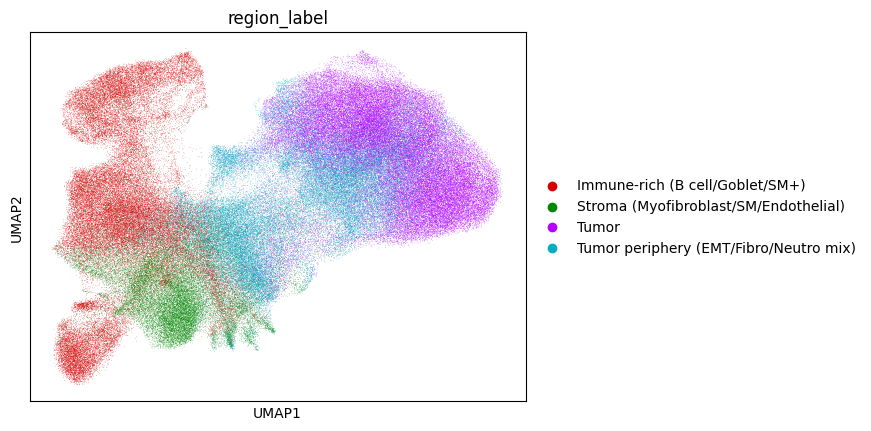

In [13]:
sc.pl.umap(
    adata,
    color=["region_label"],
    wspace=0.4,
    # save="_resolvi_leiden.png",
    palette=cc.glasbey_light,
)

/tmp/ipykernel_370622/2431296804.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


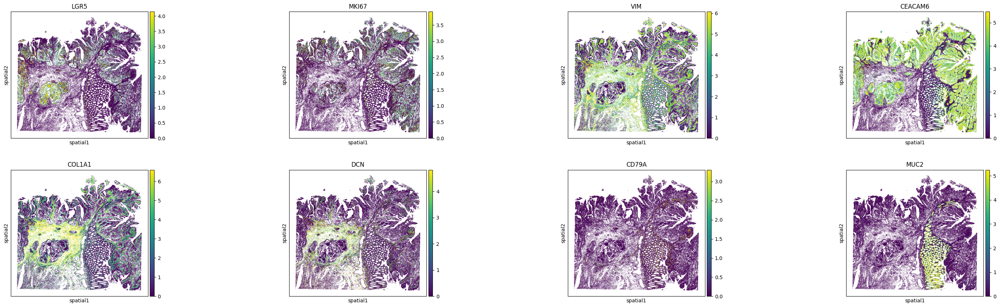

In [16]:
marker_genes = ["LGR5", "MKI67", "VIM", "CEACAM6", "COL1A1", "DCN", "CD79A", "MUC2"]
sc.pl.spatial(
    adata,
    # color=["region_label"],
    color=marker_genes,
    spot_size=50,
    wspace=0.4,
    # save="_niche_clusters.png",
    palette=cc.glasbey_light,
    vmax="p99",
    layer="log_norm",
)

In [25]:
adata

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 'region_label'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'cell_type_colors', 'cell_type_to_int', 'log1p', 'neighbors', 'rank_genes_groups', 'region_label_colors', 'resolvi_leiden_1.0_colors', 'resolvi_leiden_256_colors', 'resolvi_leiden_256_epochs150', 'resolvi_leiden_256_epochs150_colors', 'resolvi_leiden_colors', 'sample_colors', 'umap'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6', 'distance_neighbor', 'index_neighbor', 'neighborh

In [4]:
adata_annot = sc.read_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_resolvi_annotated.h5ad")
print(adata_annot)

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'cell_type_colors', 'cell_type_to_int', 
'log1p', 'neighbors', 'rank_genes_groups', 'region_label_colors', 'resolvi_leiden_1.0_colors', 
'resolvi_leiden_256_colors', 'resolvi_leiden_256_epochs150', 'resolvi_leiden_256_epochs150_colors', 
'resolvi_leiden_colors', 'sample_colors', 'umap'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6', 
'distance_neighbor', 'index_neighbor', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m_niche_ct', 'spatial'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'

In [20]:
# adata.write_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_resolvi_annotated.h5ad")

In [14]:
# Legacy version (only counts in .X)
import anndata as ad
adata_legacy = ad.AnnData(
    X=adata_annot.X.copy(),
    obs=adata_annot.obs.copy(),
    var=adata_annot.var.copy(),
)

adata_legacy.obsm = adata_annot.obsm.copy()
adata_legacy.layers["counts"] = adata_annot.layers["counts"].copy()

print(adata_legacy)

# adata_legacy.write("/home/nathanl/Data/VisiumHD_CRC/adata_legacy.h5ad", as_dense=["X"])

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6', 
'distance_neighbor', 'index_neighbor', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m_niche_ct', 'spatial'
    layers: 'counts'

In [15]:
sc.pp.filter_cells(adata_legacy, min_counts=10)
print(adata_legacy)

AnnData object with n_obs × n_vars = 220289 × 10000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6', 
'distance_neighbor', 'index_neighbor', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m_niche_ct', 'spatial'
    layers: 'counts'

In [23]:
adata_legacy.X[0].toarray().max()

np.float32(4.8091035)

In [16]:
sc.pp.highly_variable_genes(
    adata_legacy,
    n_top_genes=1000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    # batch_key="cell_source",
)
adata_legacy.write("/home/nathanl/Data/VisiumHD_CRC/adata_legacy_hvg1k.h5ad", as_dense=["X"])

# UMAPs 

In [4]:
adata_plot = sc.read_h5ad("/home/nathanl/Data/VisiumHD_CRC/adata_legacy_hvg4k.h5ad")
print(adata_plot)

AnnData object with n_obs × n_vars = 217589 × 4000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label', 'flipped_cell_type', 'flipped_cell_type_0.0', '_scvi_sample', 'flipped_cell_type_0.01', 
'flipped_cell_type_0.05', 'flipped_cell_type_0.1', 'flipped_cell_type_0.2', 'flipped_cell_type_0.4', 
'flipped_cell_type_0.6', 'flipped_cell_type_1.0', 'ln_s10_w400_scanvi_lr0.0005_poisson_compo_error', 
'ln_s10_w400_scanvi_lr0.0005_poisson_niche_error'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'flipped_cell_type_0.01_colors', 
'flipped_cell_type_0.05_colors', 'flipped_cell_type_0.0_colors', 'flipped_cell_type_0.1_colors', 
'flipped_cell_type_0.2_colors', 'flipped_cell_type_0.4_colors', 'flipped_cell_type_0.6_colors', 
'flipped_cell_type_1.0_colors', 'hvg', 'neighbors', 'umap'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_scanvi', 'X_scanvi_seed123_flip0.0', 'X_scanvi_seed123_flip0.01', 'X_scanvi_seed123_flip0.05', 
'X_scanvi_seed123_flip0.1', 'X_scanvi_seed123_flip0.2', 'X_scanvi_seed123_flip0.4', 'X_scanvi_seed123_flip0.6', 
'X_scanvi_seed123_flip1.0', 'X_scanvi_seed34_flip0.0', 'X_scanvi_seed34_flip0.01', 'X_scanvi_seed34_flip0.05', 
'X_scanvi_seed34_flip0.1', 'X_scanvi_seed34_flip0.2', 'X_scanvi_seed34_flip0.4', 'X_scanvi_seed34_flip0.6', 
'X_scanvi_seed34_flip1.0', 'X_scanvi_seed42_flip0.0', 'X_scanvi_seed42_flip0.01', 'X_scanvi_seed42_flip0.05', 
'X_scanvi_seed42_flip0.1', 'X_scanvi_seed42_flip0.2', 'X_scanvi_seed42_flip0.4', 'X_scanvi_seed42_flip0.6', 
'X_scanvi_seed42_flip1.0', 'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 
'banksy_pc_20_lambda_0.6', 'distance_neighbor', 
'eta0_f0_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.0', 
'eta0_f0_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.0', 
'eta0_f0_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.0', 
'eta0_f100_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip1.0', 
'eta0_f100_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip1.0', 
'eta0_f100_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip1.0', 
'eta0_f10_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.1', 
'eta0_f10_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.1', 
'eta0_f10_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.1', 
'eta0_f1_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.01', 
'eta0_f1_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.01', 
'eta0_f1_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.01', 
'eta0_f20_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.2', 
'eta0_f20_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.2', 
'eta0_f20_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.2', 
'eta0_f40_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.4', 
'eta0_f40_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.4', 
'eta0_f40_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.4', 
'eta0_f5_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.05', 
'eta0_f5_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.05', 
'eta0_f5_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.05', 
'eta0_f60_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.6', 
'eta0_f60_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.6', 
'eta0_f60_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.6', 
'f0_s10_scanvi_lr0.0005_poisson_X_nicheVI_seed34_flip0.0', 
'f0_s10_scanvi_lr0.0005_poisson_seed123_X_nicheVI_seed123_flip0.0', 
'f0_s10_scanvi_lr0.0005_poisson_seed34_X_nicheVI_seed34_flip0.0', 
'f0_s10_scanvi_lr0.0005_poisson_seed42_X_nicheVI_seed42_flip0.0', 
'f100_s10_scanvi_lr0.0005_poisson_X_nicheVI_seed34_flip1.0', 

In [5]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_plot, n_neighbors=20, use_rep="ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI")
sc.tl.umap(adata_plot, min_dist=0.3)

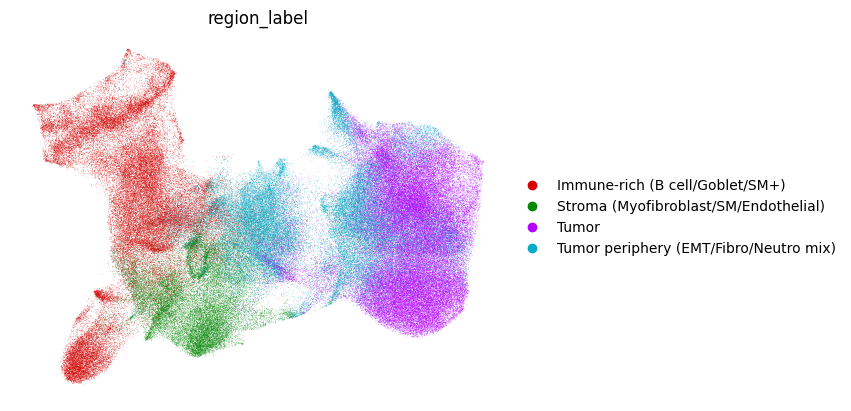

In [6]:
sc.pl.umap(
    adata_plot,
    color=["region_label"],
    wspace=0.4,
    # save="_resolvi_leiden.png",
    palette=cc.glasbey_light,
    frameon=False,
    show=False,
)
plt.savefig("/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/umap_region.png", bbox_inches="tight", dpi=500)
plt.savefig("/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/umap_region.svg", bbox_inches="tight", dpi=500)

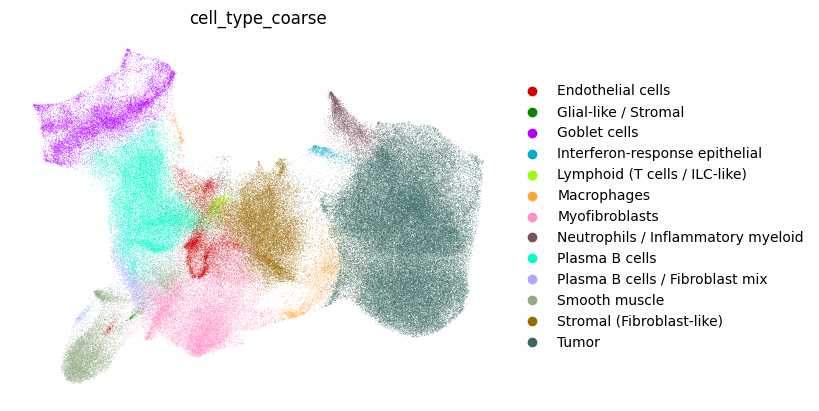

In [7]:
sc.pl.umap(
    adata_plot,
    color=["cell_type_coarse"],
    wspace=0.4,
    # save="_resolvi_leiden.png",
    palette=cc.glasbey_light,
    frameon=False,
    show=False,
)
plt.savefig("/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/umap_celltype_coarse.png", bbox_inches="tight", dpi=500)
plt.savefig("/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/umap_celltype_coarse.svg", bbox_inches="tight", dpi=500)

In [8]:
sc.settings._vector_friendly = True

/tmp/ipykernel_593111/525356392.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


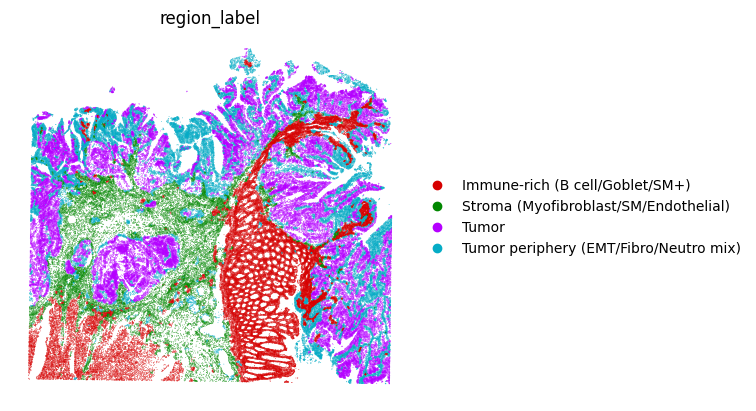

In [9]:
sc.pl.spatial(
    adata_plot,
    color=["region_label"],
    wspace=0.4,
    # save="_resolvi_leiden.png",
    palette=cc.glasbey_light,
    frameon=False,
    show=False,
    spot_size=50,
)
plt.savefig(
    "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/spatial_region.png",
    bbox_inches="tight",
    dpi=300,
)
plt.savefig(
    "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/spatial_region.svg",
    bbox_inches="tight",
    dpi=300,
)

/tmp/ipykernel_593111/1801594612.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comp = adata_plot.obs.groupby(["region_label", "cell_type_coarse"]).size().unstack(fill_value=0)


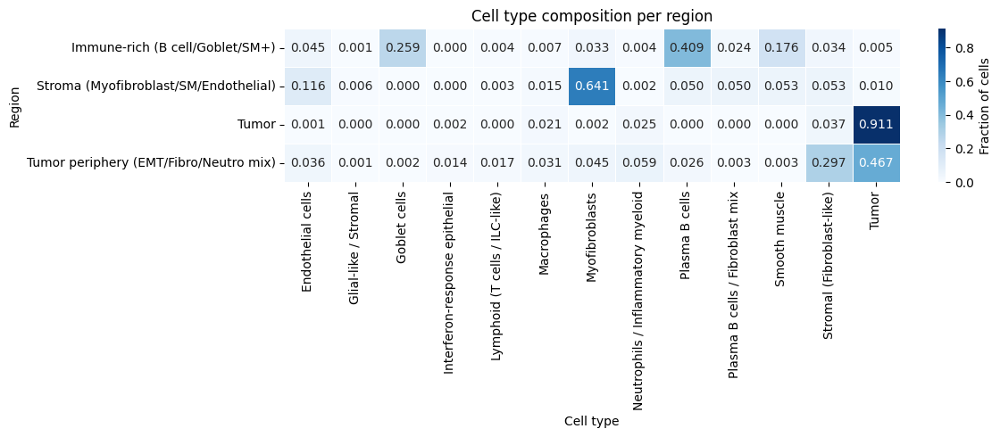

In [10]:
import seaborn as sns

# Cell type composition per region — heatmap
comp = adata_plot.obs.groupby(["region_label", "cell_type_coarse"]).size().unstack(fill_value=0)
comp_norm = comp.div(comp.sum(axis=1), axis=0)  # row-normalize to fractions

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    comp_norm,
    cmap="Blues",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Fraction of cells"},
)
ax.set_xlabel("Cell type")
ax.set_ylabel("Region")
ax.set_title("Cell type composition per region")
plt.tight_layout()
plt.savefig(
    "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/composition_heatmap.png",
    bbox_inches="tight",
    dpi=300,
)
plt.savefig(
    "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/composition_heatmap.svg",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

/tmp/ipykernel_593111/317715877.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


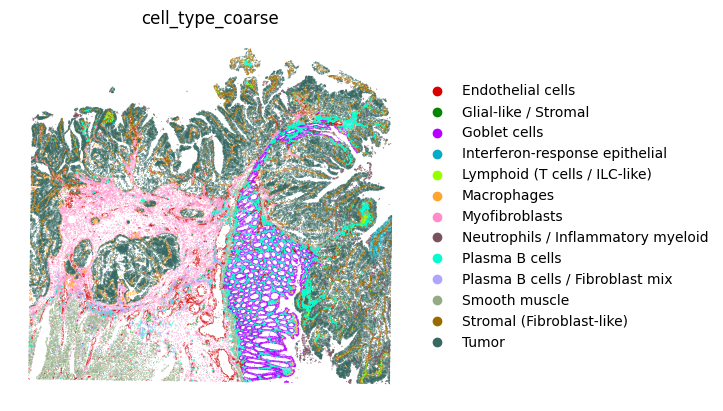

In [11]:
sc.pl.spatial(
    adata_plot,
    color=["cell_type_coarse"],
    wspace=0.4,
    # save="_resolvi_leiden.png",
    palette=cc.glasbey_light,
    frameon=False,
    show=False,
    spot_size=50,
)
plt.savefig(
    "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/spatial_celltype_coarse.png",
    bbox_inches="tight",
    dpi=500,
)
plt.savefig(
    "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/spatial_celltype_coarse.svg",
    bbox_inches="tight",
    dpi=500,
)

In [5]:
adata_plot.obs["cell_type_coarse"].value_counts()

cell_type_coarse
Tumor                                 94641
Plasma B cells                        26893
Stromal (Fibroblast-like)             23448
Myofibroblasts                        22236
Goblet cells                          15322
Smooth muscle                         11962
Endothelial cells                      7973
Neutrophils / Inflammatory myeloid     5554
Macrophages                            4115
Plasma B cells / Fibroblast mix        2907
Lymphoid (T cells / ILC-like)          1321
Interferon-response epithelial          926
Glial-like / Stromal                    291
Name: count, dtype: int64

In [7]:
sc.tl.rank_genes_groups(
    adata_plot,
    groupby="cell_type_coarse",
    method="wilcoxon",
    key_added="rank_genes",
)

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 4000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


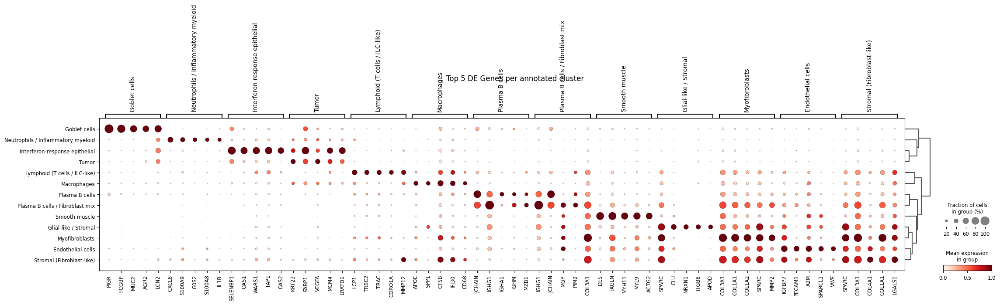

In [8]:
# Extract ranked gene information
n_genes = 5
result = adata_plot.uns["rank_genes"]
groups = result["names"].dtype.names

# Build the dictionary
top_genes = {}
for group in groups:
    top_genes[group] = list(result["names"][group][:n_genes])

# Step 4: Generate a dot plot
sc.pl.dotplot(
    adata_plot,
    var_names=top_genes,
    groupby="cell_type_coarse",
    standard_scale="var",
    title="Top 5 DE Genes per annotated cluster",
    dendrogram=True,
    show=False,
)
# plt.savefig(f"{figure_dir}/dotplot_leiden_markers.svg", dpi=500)
plt.savefig("/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/dotplot_celltype_coarse_markers.png", dpi=500)
plt.savefig("/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/dotplot_celltype_coarse_markers.svg", dpi=500)